# Laboratorio 2


Se importan librerías esenciales: os para manejar rutas, numpy para cálculo numérico, pandas para manipulación de datos, matplotlib y mpl_toolkits.mplot3d para graficación 2D y 3D, y %matplotlib inline para que las gráficas se muestren dentro del cuaderno.

In [31]:
# utilizado para manejos de directorios y rutas
#Estudiante: Valda Plaza Camila Monserrat
#Carrera: Ing. Sistemas
import os

# Computacion vectorial y cientifica para python
import numpy as np

import pandas as pd  # importar pandas

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [32]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Regresión lineal con multiples variables
En esta celda se realiza la **carga y preparación del dataset** de viviendas. Primero, se importa el archivo CSV y se reemplazan los valores faltantes: con la **moda** para variables categóricas y con la **mediana** para variables numéricas. Luego, se seleccionan las características relevantes `X` y el vector objetivo `y` (precio de las casas). A continuación, se divide el conjunto de datos en **entrenamiento y prueba** usando un 20% para testeo y 80% para entrenamiento, garantizando reproducibilidad con `random_state=42`. Finalmente, se muestran tamaños de los conjuntos y una vista de las primeras filas para verificar los datos cargados.


In [33]:

from sklearn.model_selection import train_test_split
df = pd.read_csv('/content/gdrive/MyDrive/IA - LABORATORIOS /Lab2-VersionEditada/melb_data.csv')

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

X = df[['Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
        'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude',
        'Propertycount']].values
y = df['Price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño total de datos:", len(y))
print("Entrenamiento:", len(y_train))
print("Prueba:", len(y_test))
print()

print('{:>10s}{:>10s}{:>12s}'.format('X[:,0]', 'X[:,1]', 'y'))
print('-'*36)
for i in range(10):
    print('{:10.0f}{:10.0f}{:12.0f}'.format(X_train[i, 0], X_train[i, 1], y_train[i]))


Tamaño total de datos: 13580
Entrenamiento: 10864
Prueba: 2716

    X[:,0]    X[:,1]           y
------------------------------------
        14         4     1480000
        14         3     1530000
         5         2      690000
         3         2      570000
        13         4     1041000
         3         3     1305000
        14         4     1270000
         5         5     3175000
         9         4     1700000
        17         4     1171000


La función `featureNormalize` recibe una matriz de datos y devuelve una versión normalizada, donde a cada columna se le resta su media y se divide entre su desviación estándar; además, retorna los valores de la media y la desviación de cada columna para poder reutilizarlos.


In [34]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


En esta celda se normalizan las características del conjunto de entrenamiento y prueba. Se calcula la media (`mu`) y la desviación estándar (`sigma`) con `featureNormalize`, y se usan para escalar los datos de forma uniforme. Esto mejora la estabilidad del modelo. Al final, se muestran los valores de `mu`, `sigma` y las primeras filas normalizadas para verificar el resultado.
Llama featureNormalize con los datos cargados

In [ ]:
X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma  # Para test

print("Media calculada (mu):")
print(mu)
print("\nDesviación estándar calculada (sigma):")
print(sigma)

print("\nPrimeras 5 filas de X normalizado:")
print(X_train_norm[:5, :])


Media calculada (mu):
[ 1.00987942e+01  2.91365979e+00  1.53497791e+00  1.60916789e+00  5.24160254e+02  1.40780656e+02  1.96703571e+03 -3.78092015e+01  1.44994875e+02  7.46312058e+03]

Desviación estándar calculada (sigma):
[5.88766507e+00 9.70525347e-01 6.89890468e-01 9.60491965e-01 1.38043461e+03 4.37354766e+02 2.84027196e+01 7.89956902e-02 1.03938569e-01 4.37895872e+03]

Primeras 5 filas de X normalizado:
[[ 0.69657594  1.11933213  0.67405206  0.40690825  0.12375794  0.04394452  0.10436626 -0.6591303   1.42232838  1.34800983]
 [ 0.69657594  0.08896234 -0.7754534   0.40690825  0.20706504 -0.03379557  0.10436626 -0.74913521  1.46013918  1.34800983]
 [-0.93395159 -0.94140745 -0.7754534  -0.63422487 -0.32030511 -0.03379557  0.10436626 -0.1113789   0.30715043  0.87803509]
 [-1.17173686 -0.94140745 -0.7754534  -0.63422487 -0.37970669 -0.14811924  0.28040574  0.24053904 -0.23932621 -0.99501294]
 [ 0.49276     1.11933213  0.67405206 -0.63422487 -0.1681791  -0.03379557  0.10436626 -1.3367622

En esta celda se agrega una columna de unos al inicio del conjunto de entrenamiento normalizado para incluir el **término de sesgo (bias)** en el modelo. Luego, se ajusta la configuración de `NumPy` para mostrar los valores con alta precisión y en notación científica, facilitando la revisión de los datos. Finalmente, se imprime una vista de las primeras 15 filas de la matriz resultante `X_train_bias`, mostrando cada fila completa en una sola línea para una mejor visualización.

In [36]:
# Agregamos la columna de unos al inicio
m = X_train_norm.shape[0]
X_train_bias = np.concatenate([np.ones((m, 1)), X_train_norm], axis=1)

import numpy as np

# Configurar numpy para mostrar toda la precisión y notación científica
np.set_printoptions(precision=8, suppress=False, linewidth=200)

# Imprimir estilo tabla, cada fila en una línea
print(np.array2string(X_train_bias[:15], formatter={'float_kind':lambda x: f"{x: .8e}"}))


[[ 1.00000000e+00  6.96575938e-01  1.11933213e+00  6.74052060e-01  4.06908251e-01  1.23757942e-01  4.39445177e-02  1.04366263e-01 -6.59130296e-01  1.42232838e+00  1.34800983e+00]
 [ 1.00000000e+00  6.96575938e-01  8.89623403e-02 -7.75453399e-01  4.06908251e-01  2.07065038e-01 -3.37955748e-02  1.04366263e-01 -7.49135207e-01  1.46013918e+00  1.34800983e+00]
 [ 1.00000000e+00 -9.33951595e-01 -9.41407452e-01 -7.75453399e-01 -6.34224872e-01 -3.20305106e-01 -3.37955748e-02  1.04366263e-01 -1.11378895e-01  3.07150432e-01  8.78035091e-01]
 [ 1.00000000e+00 -1.17173686e+00 -9.41407452e-01 -7.75453399e-01 -6.34224872e-01 -3.79706688e-01 -1.48119240e-01  2.80405743e-01  2.40539038e-01 -2.39326209e-01 -9.95012938e-01]
 [ 1.00000000e+00  4.92759996e-01  1.11933213e+00  6.74052060e-01 -6.34224872e-01 -1.68179103e-01 -3.37955748e-02  1.04366263e-01 -1.33676220e+00  2.83097763e-01 -1.52575218e-01]
 [ 1.00000000e+00 -1.25666017e+00  8.89623403e-02 -7.75453399e-01  4.06908251e-01 -2.53659428e-01 -7.0379

### Descenso por el gradiente



Esta función `computeCostMulti` calcula el costo. Recibe como parámetros la matriz de características `X`, el vector de valores reales `y` y los parámetros del modelo `theta`. Primero obtiene el número de ejemplos de entrenamiento `m`, luego calcula la diferencia entre las predicciones del modelo (`np.dot(X, theta)`) y los valores reales `y`, eleva esas diferencias al cuadrado, las suma y finalmente divide entre `2m`. El resultado `J` representa el error promedio cuadrático del modelo, que sirve para evaluar qué tan bien se ajustan los parámetros `theta` a los datos.


In [37]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

gradientDescentMulti implementa el descenso por gradiente para múltiples variables.
Recibe los datos de entrada, las etiquetas, los parámetros iniciales, la tasa de aprendizaje y el número de iteraciones.
En cada iteración actualiza theta minimizando el costo y guarda la evolución en J_history.
Finalmente retorna los parámetros ajustados y el historial de costos.

In [38]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

En esta celda se entrena. Primero, se escalan los valores objetivo (`y_train`) a millones para facilitar el cálculo y se inicializan los parámetros (`theta`) en cero. Luego, se ejecuta la función `gradientDescentMulti`, que ajusta los parámetros del modelo iterativamente con una tasa de aprendizaje (`alpha`) y un número definido de iteraciones (`num_iters`). Se grafica la **función de costo (J)** a lo largo de las iteraciones para visualizar la convergencia del entrenamiento. Finalmente, se utiliza el vector `theta` obtenido para predecir el precio de una nueva casa, normalizando sus características con la misma media y desviación estándar del entrenamiento, y se muestra el resultado estimado en dólares.


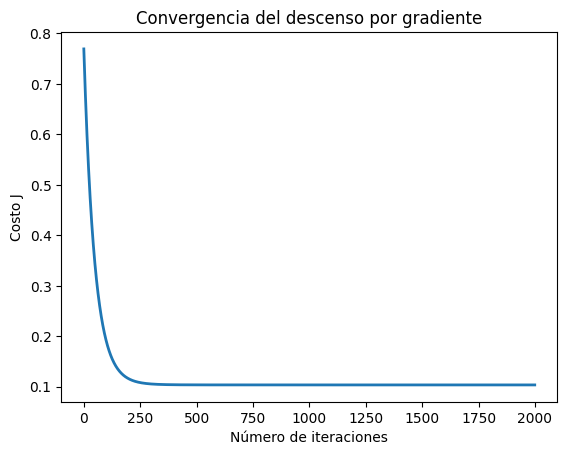

theta calculado por el descenso por el gradiente: [ 1.07496493 -0.22404631  0.22988046  0.16462905  0.0628748   0.01915171  0.02148634 -0.13787596 -0.11467936  0.09666682 -0.0090528 ]
El precio predecido: $971647


In [39]:
from matplotlib import pyplot

y_scaled = y_train / 1_000_000

alpha = 0.01
num_iters = 2000

theta = np.zeros(X_train_bias.shape[1])

theta, J_history = gradientDescentMulti(X_train_bias, y_scaled, theta, alpha, num_iters)

pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por gradiente')
pyplot.show()

print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# --- Predicción para una nueva casa
X_array = np.array([1, 10, 3, 2, 2, 500, 120, 2000, -37.8, 144.9, 8000], dtype=float)

# Normalizar características usando mu y sigma del entrenamiento
X_array[1:] = (X_array[1:] - mu) / sigma
X_array = np.nan_to_num(X_array)

# Calcular precio predicho (reconvertir a millones)
price = np.dot(X_array, theta) * 1_000_000

print('El precio predecido: ${:.0f}'.format(price))


En esta celda se construye el vector de características de una nueva casa para realizar una **predicción de precio** usando el modelo entrenado. Primero, se define el arreglo `X_array` con los valores de cada variable, incluyendo el 1 inicial correspondiente al término de sesgo. Luego, se normalizan las características aplicando la media (`mu`) y la desviación estándar (`sigma`) obtenidas durante el entrenamiento, garantizando coherencia con los datos del modelo. Posteriormente, se eliminan posibles valores no numéricos (`NaN`) y se calcula el precio estimado mediante el producto punto entre `X_array` y los parámetros `theta`, reescalando el resultado a dólares. Finalmente, se muestra el precio predicho en formato legible.


In [40]:
# Crear el vector de características de la casa a predecir
X_array = np.array([1, 5.0, 3, 2, 1, 600, 150, 1995, -37.8, 144.9, 7000], dtype=float)

# Normalizar usando mu y sigma del entrenamiento
X_array[1:] = (X_array[1:] - mu) / sigma
X_array = np.nan_to_num(X_array)  # por si hay NaN

# Predecir precio (recordar multiplicar por 1_000_000 si y fue escalado)
price = np.dot(X_array, theta) * 1_000_000

print('El precio predecido: ${:.0f}'.format(price))


El precio predecido: $1125654


En esta celda se calcula el **precio final predicho** de una vivienda utilizando el modelo entrenado. Se realiza el producto punto entre el vector de características `X_array` y los parámetros del modelo `theta`, y luego se multiplica por un millón para **reconvertir el valor a la escala original** del precio. Finalmente, se imprime el resultado en formato legible, mostrando el valor estimado para una casa con las características específicas indicadas.

In [41]:
price = np.dot(X_array, theta) * 1000000  # Desescalar el precio

print('El precio predecido para una casa a 5km del CBD, con 3 dormitorios, 2 baños y 150m2 (usando el descenso por el gradiente): ${:.0f}'.format(price))

El precio predecido para una casa a 5km del CBD, con 3 dormitorios, 2 baños y 150m2 (usando el descenso por el gradiente): $1125654



### Ecuacion de la Normal


En esta celda se define la función **`normalEqn`**, que calcula los parámetros óptimos `theta` de una regresión lineal utilizando la **ecuación normal**. Este método obtiene la solución analítica del modelo sin necesidad de iteraciones.

Dentro de la función, primero se inicializa `theta` con ceros y luego se aplica la fórmula usando operaciones matriciales de `NumPy`. El resultado es un vector `theta` que minimiza el error cuadrático del modelo de forma exacta.

In [42]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

En esta celda se aplica la **ecuación normal** para calcular directamente los parámetros óptimos `theta` del modelo de regresión lineal. Primero, se configura `NumPy` para mostrar los resultados con alta precisión. Luego, se agrega una columna de unos al conjunto de entrenamiento original (`X_train`) para incluir el **término de sesgo**. A continuación, se llama a la función `normalEqn` para obtener `theta` mediante la solución analítica. Finalmente, se imprime el vector resultante con formato científico, mostrando los valores precisos de los coeficientes calculados.


In [ ]:
import numpy as np

np.set_printoptions(precision=8, suppress=False, linewidth=200)

X_train_original = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)

theta = normalEqn(X_train_original, y_train)

print("Theta calculado a partir de la ecuación normal:")
print(np.array2string(theta, formatter={'float_kind':lambda x: f"{x: .8e}"}))



Theta calculado a partir de la ecuación normal (formato ingeniero):
[-1.79908838e+08 -3.80598439e+04  2.36954250e+05  2.38520021e+05  6.54529059e+04  1.38742728e+01  4.91367954e+01 -4.85318276e+03 -1.45193649e+06  9.30083688e+05 -2.06673741e+00]


Se realiza la **predicción del precio de una casa** utilizando los parámetros obtenidos mediante la **ecuación normal**. Primero, se crea el vector `X_array` con las características de la vivienda, incluyendo el 1 inicial correspondiente al término de sesgo. Luego, se calcula el precio estimado mediante el producto punto entre `X_array` y `theta`, que contiene los coeficientes del modelo. Finalmente, se imprime el valor predicho en dólares, mostrando el resultado de la estimación de forma clara y legible.


In [44]:
# Crear vector de características de la casa a predecir
X_array = np.array([1, 5.0, 3, 2, 1, 600, 150, 1995, -37.8, 144.9, 7000], dtype=float)

# Predecir usando theta de la ecuación normal
price = np.dot(X_array, theta)

print('Precio predicho para una casa a 5km del CBD, con 3 dormitorios, 2 baños y 150m2 (ecuación normal): ${:.0f}'.format(price))


Precio predicho para una casa a 5km del CBD, con 3 dormitorios, 2 baños y 150m2 (ecuación normal): $1125673


En esta celda se evalúa el **desempeño del modelo** usando el conjunto de prueba. Primero, se normalizan las características de `X_test` y se agrega la columna de unos para incluir el término de sesgo. Luego, se calculan las predicciones de precio usando los parámetros obtenidos por **descenso por gradiente** y por **ecuación normal**. A continuación, se calcula el **RMSE (Root Mean Squared Error)** de ambas predicciones para medir la precisión de los modelos. Finalmente, se imprimen los resultados de RMSE y las primeras predicciones comparadas con los valores reales, mostrando la diferencia entre los métodos y la realidad.


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

X_test_norm = (X_test - mu) / sigma

# Agregar columna de unos
X_test_bias = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

# Predecir precios usando theta de gradiente descendente
y_pred_gd = np.dot(X_test_bias, theta) * 1_000_000  # recordando que y estaba escalado

X_test_original = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

theta_normal = normalEqn(np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1), y_train)

y_pred_ne = np.dot(X_test_original, theta_normal)

rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
rmse_ne = np.sqrt(mean_squared_error(y_test, y_pred_ne))

print(f"RMSE Gradiente Descendente: ${rmse_gd:,.0f}")
print(f"RMSE Ecuación Normal: ${rmse_ne:,.0f}")

print("\nPrimeras 5 predicciones vs valor real:")
for i in range(100):
    print(f"Gradiente: ${y_pred_gd[i]:,.0f}, Ecuación Normal: ${y_pred_ne[i]:,.0f}, Real: ${y_test[i]:,.0f}")


RMSE Gradiente Descendente: $179,905,611,566,442
RMSE Ecuación Normal: $446,084

Primeras 5 predicciones vs valor real:
Gradiente: $-177,469,185,250,404, Ecuación Normal: $1,405,626, Real: $2,600,000
Gradiente: $-180,696,895,944,876, Ecuación Normal: $794,030, Real: $620,000
Gradiente: $-179,162,291,757,022, Ecuación Normal: $1,247,937, Real: $1,000,000
Gradiente: $-182,040,984,984,133, Ecuación Normal: $785,388, Real: $430,000
Gradiente: $-180,949,043,410,492, Ecuación Normal: $711,827, Real: $392,250
Gradiente: $-180,459,925,330,058, Ecuación Normal: $956,522, Real: $700,000
Gradiente: $-181,733,068,289,100, Ecuación Normal: $494,865, Real: $439,000
Gradiente: $-180,099,214,092,542, Ecuación Normal: $2,012,010, Real: $2,236,000
Gradiente: $-182,415,553,252,356, Ecuación Normal: $563,855, Real: $671,000
Gradiente: $-179,520,819,733,180, Ecuación Normal: $1,138,419, Real: $1,870,000
Gradiente: $-177,755,239,653,088, Ecuación Normal: $1,662,250, Real: $2,525,000
Gradiente: $-180,997,863

## Ejercicio de programación Regresión Polinomial



La carga de datos se encuentra en la primera parte. No es necesario repetir el mismo proceso para evitar errores al llamado de variables, etc.

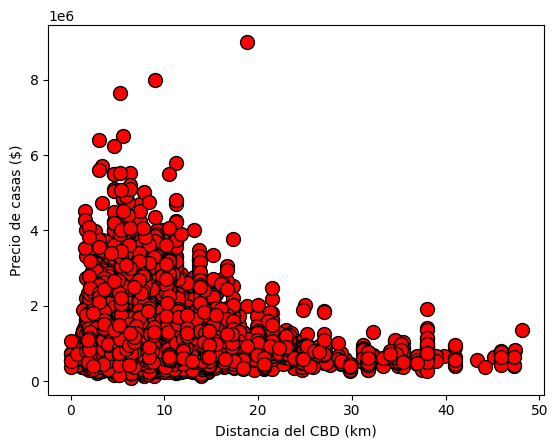

In [ ]:
def plotData(x, y):
    fig = pyplot.figure()  
    pyplot.plot(x, y, 'ro', ms=10, mec='k')
    pyplot.ylabel('Precio de casas ($)')
    pyplot.xlabel('Distancia del CBD (km)')
    pyplot.show()

plotData(df['Distance'].values, y)


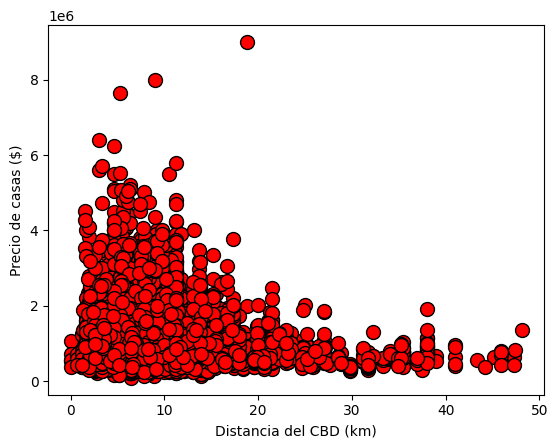

In [47]:
plotData(X_train[:,0], y_train)


En esta celda se crean **características polinomiales** de segundo grado para el conjunto de entrenamiento. Se concatenan las variables originales de `X_train` con sus cuadrados (`X_train**2`), aumentando la capacidad del modelo para capturar relaciones **no lineales** entre las variables y el precio. Finalmente, se imprimen las primeras cinco filas de la nueva matriz `X_poly` para visualizar cómo quedaron las características originales y cuadráticas combinadas.


In [ ]:

X_poly = np.concatenate([X_train, X_train**2], axis=1)
print("Primeras filas de X_poly (características + cuadráticas):")
print(X_poly[:5, :])


Primeras filas de X_poly (características + cuadráticas):
[[ 1.42000000e+01  4.00000000e+00  2.00000000e+00  2.00000000e+00  6.95000000e+02  1.60000000e+02  1.97000000e+03 -3.78612700e+01  1.45142710e+02  1.33660000e+04  2.01640000e+02  1.60000000e+01
   4.00000000e+00  4.00000000e+00  4.83025000e+05  2.56000000e+04  3.88090000e+06  1.43347577e+03  2.10664063e+04  1.78649956e+08]
 [ 1.42000000e+01  3.00000000e+00  1.00000000e+00  2.00000000e+00  8.10000000e+02  1.26000000e+02  1.97000000e+03 -3.78683800e+01  1.45146640e+02  1.33660000e+04  2.01640000e+02  9.00000000e+00
   1.00000000e+00  4.00000000e+00  6.56100000e+05  1.58760000e+04  3.88090000e+06  1.43401420e+03  2.10675471e+04  1.78649956e+08]
 [ 4.60000000e+00  2.00000000e+00  1.00000000e+00  1.00000000e+00  8.20000000e+01  1.26000000e+02  1.97000000e+03 -3.78180000e+01  1.45026800e+02  1.13080000e+04  2.11600000e+01  4.00000000e+00
   1.00000000e+00  1.00000000e+00  6.72400000e+03  1.58760000e+04  3.88090000e+06  1.43020112e+03 

En esta celda se define la función **`featureNormalize`**, que normaliza las características de un conjunto de datos. Calcula la **media (`mu`)** y la **desviación estándar (`sigma`)** de cada variable, y luego ajusta los valores restando la media y dividiendo por la desviación estándar. Esto produce `X_norm`, un conjunto de datos escalado de manera uniforme, lo cual facilita el entrenamiento de modelos de regresión al evitar que variables con magnitudes mayores dominen el aprendizaje.


In [49]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

En esta celda se normalizan las **características polinomiales** generadas previamente. Se aplica la función `featureNormalize` a `X_poly`, calculando la media (`mu_poly`) y desviación estándar (`sigma_poly`) de cada columna para escalar los datos de manera uniforme. Esto produce `X_poly_norm`, que facilita el entrenamiento del modelo polinomial al evitar que las variables con valores mayores dominen el aprendizaje. Finalmente, se muestran las primeras cinco filas para verificar la normalización.


In [50]:
# Normalizar después de agregar las columnas polinomiales
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)
print("Primeras filas de X_poly_norm:")
print(X_poly_norm[:5, :])


Primeras filas de X_poly_norm:
[[ 0.69657594  1.11933213  0.67405206  0.40690825  0.12375794  0.04394452  0.10436626 -0.6591303   1.42232838  1.34800983  0.33912184  0.91427885  0.40019067  0.10084955 -0.0259787  -0.00975475
   0.09783552  0.65824093  1.42282137  1.1506375 ]
 [ 0.69657594  0.08896234 -0.7754534   0.40690825  0.20706504 -0.03379557  0.10436626 -0.74913521  1.46013918  1.34800983  0.33912184 -0.0600363  -0.62778965  0.10084955 -0.02332966 -0.0102661
   0.09783552  0.74833739  1.46067459  1.1506375 ]
 [-0.93395159 -0.94140745 -0.7754534  -0.63422487 -0.32030511 -0.03379557  0.10436626 -0.1113789   0.30715043  0.87803509 -0.6026375  -0.7559757  -0.62778965 -0.51908416 -0.03326883 -0.0102661
   0.09783552  0.11029716  0.30685307  0.58761674]
 [-1.17173686 -0.94140745 -0.7754534  -0.63422487 -0.37970669 -0.14811924  0.28040574  0.24053904 -0.23932621 -0.99501294 -0.65961895 -0.7559757  -0.62778965 -0.51908416 -0.03337174 -0.01079723
   0.27547213 -0.24141376 -0.23968538 -0.7

En esta celda se prepara la matriz de características para el **modelo polinomial**. Primero, se configura `NumPy` para mostrar los números con alta precisión y en notación científica. Luego, se agrega una **columna de unos** al inicio de `X_poly_norm` para incluir el término de sesgo en el modelo, generando `X_poly_bias`. Finalmente, se imprimen las primeras cinco filas de esta matriz en un formato claro y legible para revisar la estructura de las características.


In [ ]:
import numpy as np

np.set_printoptions(precision=8, suppress=False, linewidth=200)

# Concatenar columna de unos
m = X_poly_norm.shape[0]
X_poly_bias = np.concatenate([np.ones((m,1)), X_poly_norm], axis=1)

print("Primeras filas de X_poly_bias (formato ingeniero):")
print(np.array2string(X_poly_bias[:5], formatter={'float_kind':lambda x: f"{x: .8e}"}))


Primeras filas de X_poly_bias (formato ingeniero):
[[ 1.00000000e+00  6.96575938e-01  1.11933213e+00  6.74052060e-01  4.06908251e-01  1.23757942e-01  4.39445177e-02  1.04366263e-01 -6.59130296e-01  1.42232838e+00  1.34800983e+00  3.39121840e-01
   9.14278852e-01  4.00190668e-01  1.00849549e-01 -2.59786959e-02 -9.75474646e-03  9.78355244e-02  6.58240934e-01  1.42282137e+00  1.15063750e+00]
 [ 1.00000000e+00  6.96575938e-01  8.89623403e-02 -7.75453399e-01  4.06908251e-01  2.07065038e-01 -3.37955748e-02  1.04366263e-01 -7.49135207e-01  1.46013918e+00  1.34800983e+00  3.39121840e-01
  -6.00363037e-02 -6.27789649e-01  1.00849549e-01 -2.33296573e-02 -1.02660995e-02  9.78355244e-02  7.48337391e-01  1.46067459e+00  1.15063750e+00]
 [ 1.00000000e+00 -9.33951595e-01 -9.41407452e-01 -7.75453399e-01 -6.34224872e-01 -3.20305106e-01 -3.37955748e-02  1.04366263e-01 -1.11378895e-01  3.07150432e-01  8.78035091e-01 -6.02637498e-01
  -7.55975701e-01 -6.27789649e-01 -5.19084158e-01 -3.32688288e-02 -1.0266

En esta celda se imprime la **matriz completa de características polinomiales con sesgo (`X_poly_bias`)**, mostrando todas las filas y columnas. 


In [52]:
print(X_poly_bias)

[[ 1.          0.69657594  1.11933213 ...  0.65824093  1.42282137  1.1506375 ]
 [ 1.          0.69657594  0.08896234 ...  0.74833739  1.46067459  1.1506375 ]
 [ 1.         -0.93395159 -0.94140745 ...  0.11029716  0.30685307  0.58761674]
 ...
 [ 1.         -1.27364483  0.08896234 ...  0.19636654  0.02585938  1.64761525]
 [ 1.          0.64562195 -0.94140745 ...  1.52099658  0.68127845  0.50388389]
 [ 1.         -0.32250377  0.08896234 ... -0.22876677 -1.22060783 -0.54651116]]


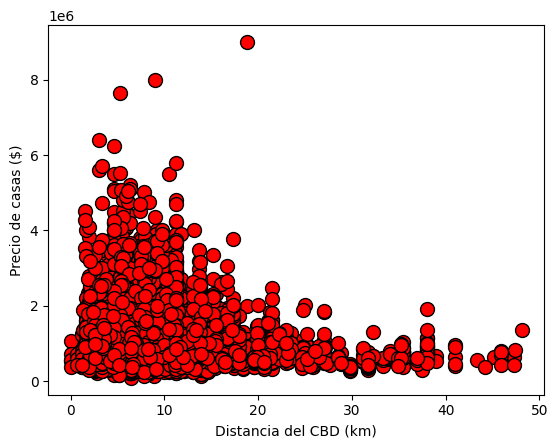

In [53]:
# Graficar relación Distance → Precio (usando conjunto de entrenamiento)
plotData(X_train[:,0], y_train)


Descenso por el gradiente Polinomial:

En esta celda se define la función **`computeCostMulti`** para calcular el **costo del modelo polinomial** de regresión lineal multivariable. Recibe la matriz de características `X` (incluyendo las columnas polinomiales y el término de sesgo), los valores reales `y` y los parámetros `theta`. Calcula las predicciones `h` como el producto punto de `X` y `theta`, y luego evalúa el **error cuadrático medio**, devolviendo el costo (J(\theta)). Esto permite medir qué tan bien el modelo polinomial se ajusta a los datos y sirve para guiar el entrenamiento con descenso por gradiente.


In [54]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

En esta celda se define la función **`gradientDescentMulti`** para entrenar un modelo polinomial de regresión lineal multivariable mediante **descenso por gradiente**. La función recibe la matriz de características `X`, los valores reales `y`, los parámetros iniciales `theta`, la tasa de aprendizaje `alpha` y el número de iteraciones `num_iters`. En cada iteración, se actualizan los parámetros restando el gradiente del costo escalado por `alpha/m`, y se guarda el valor de la función de costo en `J_history` para monitorear la convergencia. Al final, la función retorna los parámetros optimizados `theta` y el historial de costos.


In [55]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

En esta celda se completa la **predicción polinomial** de precio para una nueva casa. Primero, se entrena el modelo polinomial mediante **descenso por gradiente**, escalando `y_train` y ajustando los parámetros `theta_poly` durante 22,000 iteraciones con tasa de aprendizaje `alpha`. Se grafica la **convergencia del costo** para verificar el entrenamiento. Luego, se construye el vector de características de la casa, se generan las características polinomiales, se normalizan usando `mu_poly` y `sigma_poly`, y se agrega el término de sesgo. Finalmente, se calcula el precio estimado mediante el producto punto con `theta_poly` y se reconvierte a dólares, mostrando el resultado predicho para la vivienda específica.


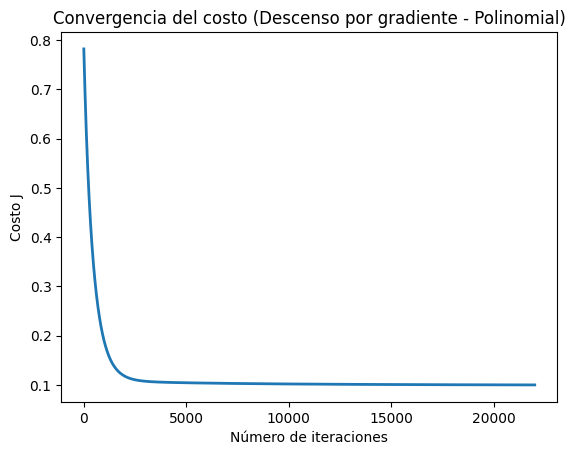

Theta polinomial calculado: [ 1.07496493 -0.23617626  0.32300581  0.11516562  0.08516099  0.04897659  0.1209508  -0.07061797 -0.05539047  0.04806268  0.05555901  0.01405079 -0.1117153   0.04654543 -0.02818391 -0.03260421
 -0.10464121 -0.06565563  0.05549947  0.04790495 -0.06914013]
Precio predicho (polinomial) para casa a 5km del CBD, 3 dormitorios, 2 baños, 150m2: $1149633


In [ ]:

y_scaled = y_train / 1_000_000

alpha = 0.001
num_iters = 22000

theta_poly = np.zeros(X_poly_bias.shape[1])
theta_poly, J_history = gradientDescentMulti(X_poly_bias, y_scaled, theta_poly, alpha, num_iters)

# --- Graficar convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo (Descenso por gradiente - Polinomial)')
pyplot.show()

print('Theta polinomial calculado: {:s}'.format(str(theta_poly)))

X_array = np.array([5.0, 3, 2, 1, 600, 150, 1995, -37.8, 144.9, 7000], dtype=float)

X_array_poly = np.concatenate([X_array, X_array**2])

X_array_poly_norm = (X_array_poly - mu_poly) / sigma_poly
X_array_poly_norm = np.nan_to_num(X_array_poly_norm)

# Agregar 1 para bias
X_array_poly_bias = np.concatenate([[1], X_array_poly_norm])

price_scaled = np.dot(X_array_poly_bias, theta_poly)
price = price_scaled * 1_000_000 

print('Precio predicho (polinomial) para casa a 5km del CBD, 3 dormitorios, 2 baños, 150m2: ${:.0f}'.format(price))


En esta celda se realiza una **regresión lineal simple** usando únicamente la característica de distancia (`Distance`). Primero, se construye `X_simple` agregando una columna de unos para el término de sesgo y se calculan los parámetros `theta_simple` mediante la **ecuación normal**. Luego, se grafican los datos originales y se genera la **línea de regresión** usando los parámetros obtenidos. Finalmente, se muestra la gráfica con etiquetas y título, permitiendo visualizar cómo el modelo simple se ajusta a los datos de precio en función de la distancia al CBD.


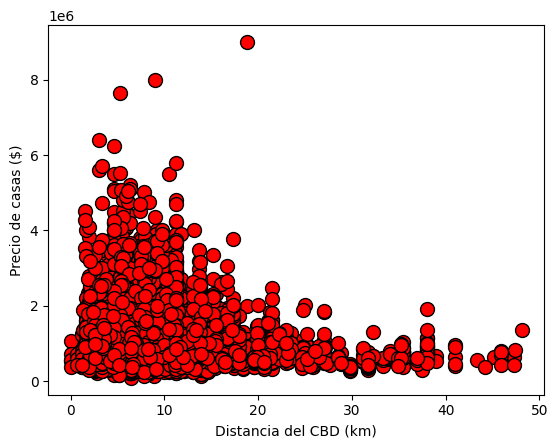

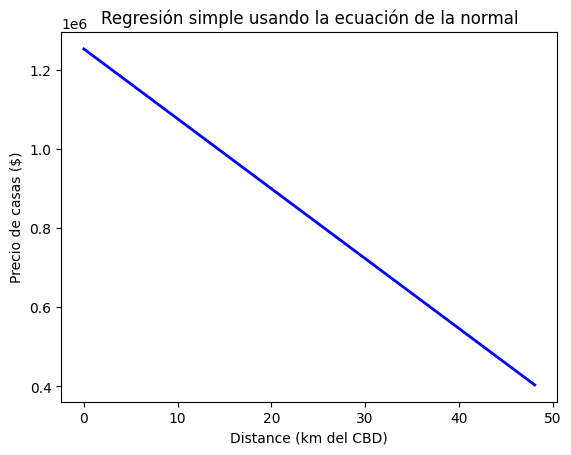

In [57]:
# Usamos solo la primera característica (Distance) para regresión simple
X_simple = np.column_stack([np.ones(X_train.shape[0]), X_train[:, 0]])  # m = X_train.shape[0]
theta_simple = normalEqn(X_simple, y_train)

# Graficar los datos
plotData(X_train[:, 0], y_train)

# Generar línea de regresión
x_line = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
y_line = theta_simple[0] + theta_simple[1] * x_line

pyplot.plot(x_line, y_line, '-', color='blue', lw=2)
pyplot.xlabel('Distance (km del CBD)')
pyplot.ylabel('Precio de casas ($)')
pyplot.title('Regresión simple usando la ecuación de la normal')
pyplot.show()


En esta celda se generan y comparan las **predicciones sobre el conjunto de prueba** utilizando los tres modelos entrenados: **descenso por gradiente multivariable**, **ecuación normal** y **modelo polinomial**. Primero, se preparan los datos de prueba, normalizando o creando las características polinomiales según corresponda y agregando la columna de unos para el sesgo. Luego, se calculan los valores predichos de precio con cada modelo y se escalan a dólares si es necesario. Finalmente, se imprimen las primeras 100 predicciones de cada modelo junto con los valores reales, permitiendo comparar visualmente la precisión de cada enfoque.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

num_predictions = min(100, X_test.shape[0])

# Predicciones Gradiente Descendente (Multi) ---
X_test_norm = (X_test - mu) / sigma
X_test_bias = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)
y_pred_gd = np.dot(X_test_bias, theta) * 1_000_000  # solo escalar

#  Predicciones Ecuación Normal 
X_test_original = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)
theta_normal = normalEqn(np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1), y_train)
y_pred_ne = np.dot(X_test_original, theta_normal)

# Predicciones Polinomial 
# Preparamos test polinomial
X_test_poly = np.concatenate([X_test, X_test**2], axis=1)
X_test_poly_norm = (X_test_poly - mu_poly) / sigma_poly
X_test_poly_bias = np.concatenate([np.ones((X_test_poly_norm.shape[0], 1)), X_test_poly_norm], axis=1)
y_pred_poly = np.dot(X_test_poly_bias, theta_poly) * 1_000_000  # solo escalar

# Imprimir las primeras 100 predicciones 
print(f"Primeras {num_predictions} predicciones sobre el test:")
for i in range(num_predictions):
    print(f"Ejemplo {i+1}: Gradiente: ${y_pred_gd[i]:,.0f}, "
          f"Ecuación Normal: ${y_pred_ne[i]:,.0f}, "
          f"Polinomial: ${y_pred_poly[i]:,.0f}, "
          f"Real: ${y_test[i]:,.0f}")



Primeras 100 predicciones sobre el test:
Ejemplo 1: Gradiente: $-177,469,185,250,404, Ecuación Normal: $1,405,626, Polinomial: $1,415,641, Real: $2,600,000
Ejemplo 2: Gradiente: $-180,696,895,944,876, Ecuación Normal: $794,030, Polinomial: $763,074, Real: $620,000
Ejemplo 3: Gradiente: $-179,162,291,757,022, Ecuación Normal: $1,247,937, Polinomial: $1,244,465, Real: $1,000,000
Ejemplo 4: Gradiente: $-182,040,984,984,133, Ecuación Normal: $785,388, Polinomial: $790,790, Real: $430,000
Ejemplo 5: Gradiente: $-180,949,043,410,492, Ecuación Normal: $711,827, Polinomial: $680,736, Real: $392,250
Ejemplo 6: Gradiente: $-180,459,925,330,058, Ecuación Normal: $956,522, Polinomial: $933,270, Real: $700,000
Ejemplo 7: Gradiente: $-181,733,068,289,100, Ecuación Normal: $494,865, Polinomial: $489,203, Real: $439,000
Ejemplo 8: Gradiente: $-180,099,214,092,542, Ecuación Normal: $2,012,010, Polinomial: $1,984,351, Real: $2,236,000
Ejemplo 9: Gradiente: $-182,415,553,252,356, Ecuación Normal: $563,85